In [3]:
url = "https://github.com/ageron/data/raw/main/ridership.tgz"

In [5]:
from pathlib import Path

folder_path = Path(r"C:\Users\user\Desktop\div\ridership")
file_path = folder_path / "ridership.tgz"
file_path.exists()

False

In [7]:
import urllib.request

urllib.request.urlretrieve(url=url, filename=file_path)

(WindowsPath('C:/Users/user/Desktop/div/ridership/ridership.tgz'),
 <http.client.HTTPMessage at 0x10ad57e7dd0>)

In [8]:
import tarfile

In [10]:
extract_dir = folder_path / 'extract'
extract_dir.mkdir(parents=True, exist_ok=True)

with tarfile.open(name=file_path) as f:
	f.extractall(extract_dir, filter='data')

In [16]:
g = extract_dir.glob("**/*.csv")
file_path = next(g)
file_path

WindowsPath('C:/Users/user/Desktop/div/ridership/extract/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv')

In [60]:
import pandas as pd

df = pd.read_csv(file_path, parse_dates=['service_date'])
df.drop('total_rides', axis='columns', inplace=True)
df.rename(columns={
	'service_date' : 'date',
	'rail_boardings' : 'rail'
}, inplace=True)
df.drop_duplicates(inplace=True)
df.sort_values('date', inplace=True)
df.set_index('date', inplace=True)
df.head(2)

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952


In [62]:
df.loc['2005':'2010', :]

,day_type,bus,rail
date,,,
2005-01-01,U,334140,196267
2005-01-02,U,373512,183672
2005-01-03,W,894571,512620
2005-01-04,W,972798,559563
2005-01-05,W,851226,558698
...,...,...,...
2010-12-27,W,673638,435925
2010-12-28,W,717933,490978
2010-12-29,W,731000,513271


In [84]:
df.loc[:, ['bus', 'rail']].resample('MS').mean()

,bus,rail
date,,
2001-01-01,807190.580645,474591.419355
2001-02-01,848889.000000,488188.178571
2001-03-01,865392.419355,498825.096774
2001-04-01,835126.366667,490444.533333
2001-05-01,862701.419355,507862.258065
...,...,...
2021-07-01,342101.096774,257660.193548
2021-08-01,353215.516129,260038.548387
2021-09-01,401958.833333,299608.366667


In [86]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


In [88]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Plot of Trig Functions')

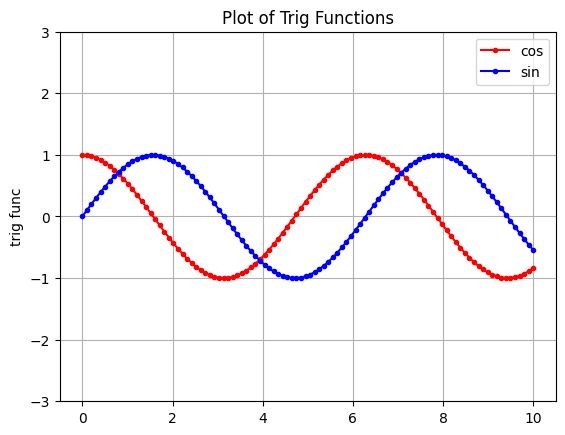

In [150]:
import numpy as np
x = np.linspace(0,10,100)
y1 = np.cos(x)
y2 = np.sin(x)

plt.plot(
	x,y1, 
	marker='.', 
	color='r', 
	# linestyle='-.', 
	# linewidth=10,
	label='cos'
	)
plt.plot(
	x,y2, 
	marker='.', 
	color='b', 
	# linestyle='-.',
	label='sin'
	)
plt.legend()
plt.grid()
plt.ylabel('trig func')
plt.ylim(-3,3)
plt.title('Plot of Trig Functions')

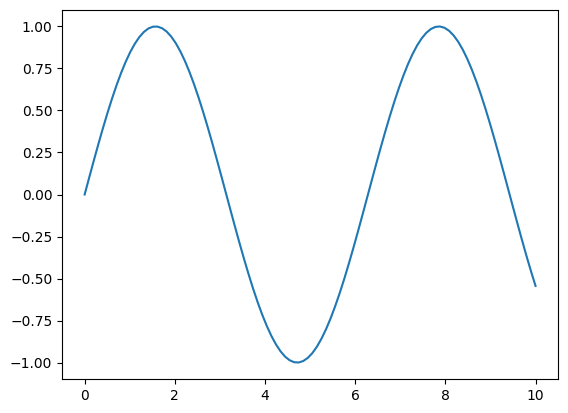

In [151]:
df.head(3)

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432


<Axes: xlabel='date'>

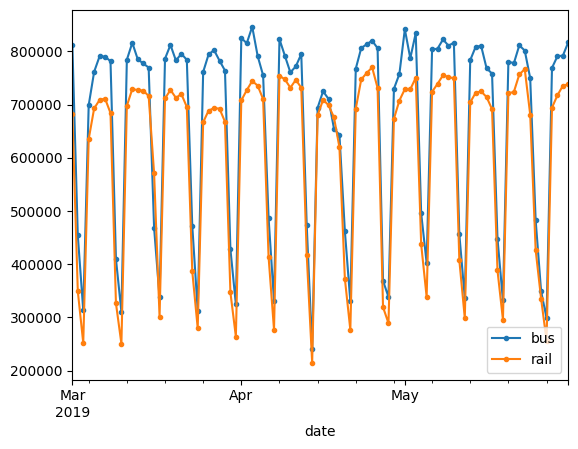

In [182]:
df_small = df.loc['2019-03':'2019-05', :]
df_small.plot(marker='.')

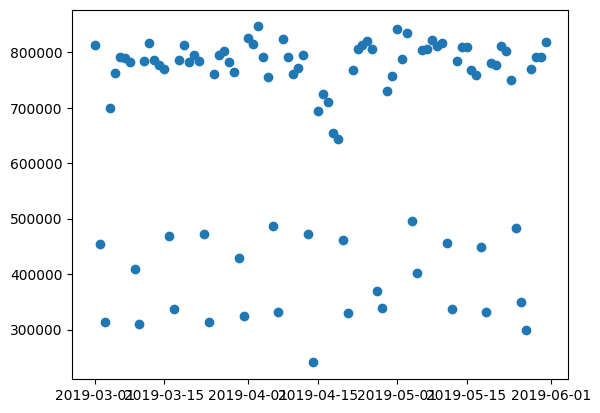

In [181]:
x = df_small.index.values
y = df_small['bus'].values

plt.scatter(x,y)

<Axes: xlabel='date'>

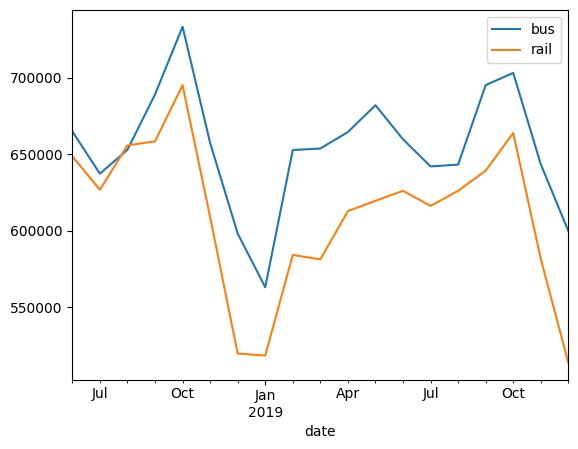

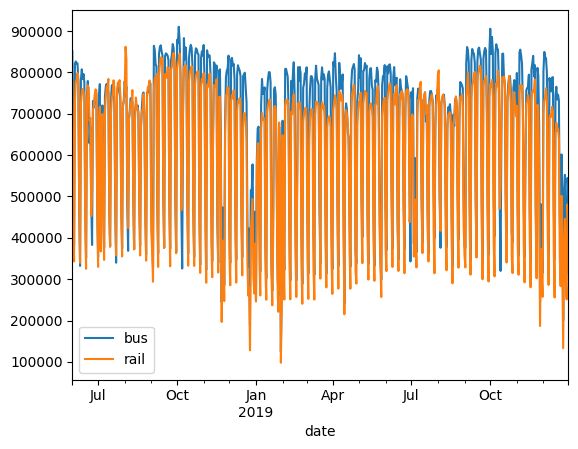

In [174]:
df_monthly = df.loc[:, ['bus', 'rail']].resample('MS').mean()
df_monthly_balaca = df_monthly.loc['2018-06':'2019-12', :]
df_monthly_balaca.plot()

df.loc['2018-06':'2019-12', :].plot()